Plotting 58 rows from /exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/seitz_master.csv


,source_kT,n_cells,n_timesteps,rho_liquid,rho_liquid_uncertainty,Q,Q_uncertainty
74,0.7,10,100000.0,0.766574,0.003042,101.626417,70.806486
15,0.7,10,100000.0,0.776600,0.003434,385.109470,81.618022
83,0.7,10,250000.0,0.761264,0.003134,20.548929,72.889833
75,0.7,10,250000.0,0.764443,0.003182,84.237971,74.010075
79,0.7,10,250000.0,0.768362,0.003137,136.030990,72.678884
354,0.7,20,100000.0,0.792564,0.000864,1262.149412,204.338332
355,0.7,20,100000.0,0.792807,0.000856,1138.683444,189.403503
453,0.7,22,100000.0,0.793663,0.000756,1695.239186,267.569387
454,0.7,22,100000.0,0.794202,0.000773,1561.256686,245.964496
455,0.7,22,100000.0,0.794543,0.000753,1540.849013,232.944270


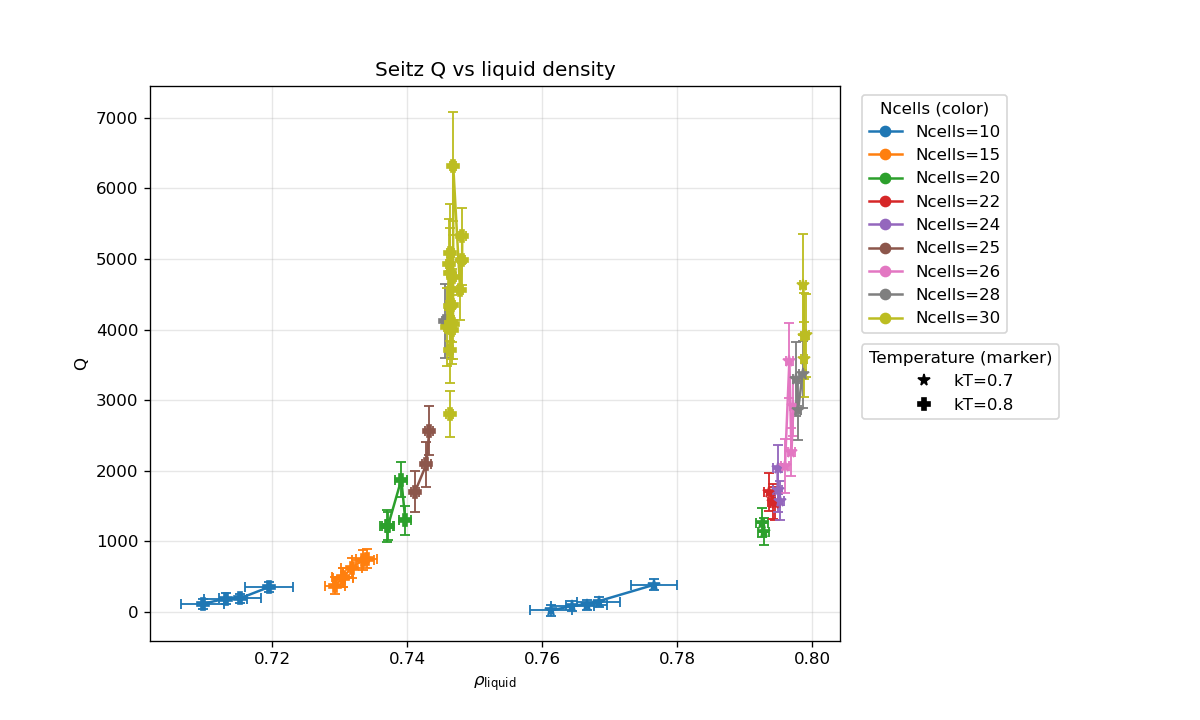

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from md_Helpers import paths
import ipympl

# Set any mask to None to keep all values for that variable.
# Examples: selected_temperatures = [0.8], selected_ncells = [30]

selected_temperatures = [0.8]
selected_temperatures = None

selected_ncells = None

selected_n_timesteps = [250000]
selected_n_timesteps = None


seitz_path = paths.MASTER_CSVS_V3_ROOT / "seitz_master.csv"
seitz = pd.read_csv(seitz_path)

if "n_timesteps" not in seitz.columns and "evolve_nsteps" in seitz.columns:
    seitz["n_timesteps"] = seitz["evolve_nsteps"]

required_columns = [
    "status",
    "Q",
    "Q_uncertainty",
    "rho_liquid",
    "rho_liquid_uncertainty",
    "source_kT",
    "n_cells",
    "n_timesteps",
]
missing = [column for column in required_columns if column not in seitz.columns]
if missing:
    raise RuntimeError(
        "Missing Seitz columns: "
        + ", ".join(missing)
        + ". Re-run Seitz_CSV.ipynb to rebuild seitz_master.csv."
    )

mask = (
    (seitz["status"] == "seitz_computed")
    & seitz["Q"].notna()
    & seitz["rho_liquid"].notna()
    & seitz["source_kT"].notna()
)

if selected_temperatures is not None:
    mask &= seitz["source_kT"].isin(selected_temperatures)
if selected_ncells is not None:
    mask &= seitz["n_cells"].isin(selected_ncells)
if selected_n_timesteps is not None:
    mask &= seitz["n_timesteps"].isin(selected_n_timesteps)

plot_data = (
    seitz[mask]
    .copy()
    .sort_values(["source_kT", "n_cells", "n_timesteps", "rho_liquid"])
)

for column in ["rho_liquid_uncertainty", "Q_uncertainty"]:
    plot_data[column] = pd.to_numeric(plot_data[column], errors="coerce")
    plot_data.loc[plot_data[column] < 0, column] = np.nan

print(f"Plotting {len(plot_data)} rows from {seitz_path}")
display(
    plot_data[[
        "source_kT",
        "n_cells",
        "n_timesteps",
        "rho_liquid",
        "rho_liquid_uncertainty",
        "Q",
        "Q_uncertainty",
    ]]
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

ncells_values = sorted(plot_data["n_cells"].dropna().unique())
temperature_values = sorted(plot_data["source_kT"].dropna().unique())
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
marker_cycle = ["*", "P", "^", "D", "v", "s", "X", "o"]
ncells_colors = {
    n_cells: color_cycle[index % len(color_cycle)]
    for index, n_cells in enumerate(ncells_values)
}
temperature_markers = {
    kT: marker_cycle[index % len(marker_cycle)]
    for index, kT in enumerate(temperature_values)
}

for (kT, n_cells, n_timesteps), group in plot_data.groupby(
    ["source_kT", "n_cells", "n_timesteps"]
):
    xerr = group["rho_liquid_uncertainty"].to_numpy()
    yerr = group["Q_uncertainty"].to_numpy()
    ax.errorbar(
        group["rho_liquid"],
        group["Q"],
        xerr=None if np.isnan(xerr).all() else xerr,
        yerr=None if np.isnan(yerr).all() else yerr,
        color=ncells_colors[n_cells],
        marker=temperature_markers[kT],
        linestyle="-",
        linewidth=1.5,
        markersize=7,
        capsize=3,
        elinewidth=1.1,
        capthick=1.1,
    )

ncells_handles = [
    Line2D(
        [0],
        [0],
        color=ncells_colors[n_cells],
        marker="o",
        linestyle="-",
        label=f"Ncells={int(n_cells)}",
    )
    for n_cells in ncells_values
]
temperature_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        marker=temperature_markers[kT],
        linestyle="None",
        markersize=7,
        label=f"kT={kT:g}",
    )
    for kT in temperature_values
]

ncells_legend = ax.legend(
    handles=ncells_handles,
    title="Ncells (color)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.add_artist(ncells_legend)
ax.legend(
    handles=temperature_handles,
    title="Temperature (marker)",
    bbox_to_anchor=(1.02, 0.55),
    loc="upper left",
)

ax.set_xlabel(r"$\rho_\mathrm{liquid}$")
ax.set_ylabel("Q")
ax.set_title("Seitz Q vs liquid density")
fig.subplots_adjust(right=0.70)
ax.grid(True, alpha=0.3)

plt.show()
